In [100]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import _LinearRegression
import OLS

import seaborn as sns

In [101]:
def Runge_func(x):
    return 1.0/(1 + 25*x**2)

In [165]:
np.random.seed(2025)

n = 1000
x = np.linspace(-1, 1, n)

std = 0.1
y = Runge_func(x) + np.random.normal(0, std, size=n)

degree = 1

x = x.reshape(-1, 1)
y = y.reshape(-1,1)

X = PolynomialFeatures(degree, include_bias=False).fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_s = scaler_y.transform(y_train)
y_test_s = scaler_y.transform(y_test)

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# scaler_minmax = MinMaxScaler()
# scaler_minmax.fit(X_train)
# X_train_minmax = scaler_minmax.transform(X_train)
# X_test_minmax = scaler_minmax.transform(X_test)

# scaler_y_minmax = MinMaxScaler()
# scaler_y_minmax.fit(y_train)
# y_train__minmax = scaler_y_minmax.transform(y_train)
# y_test_minmax = scaler_y_minmax.transform(y_test)

In [209]:
# Setup FFNN 

np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_size = 7
epochs = 100

scheduler = Adam(0.001)
ffnn = NeuralNetwork(num_input_feats, 
                     num_output_feats,
                     [200],
                     [ReLU, id_func], 
                     [ReLU_der, id_func_der],
                     scheduler, 
                     mse, 
                     mse_der,
                     regularization = "L2", reg_param=1e-6,
                     seed=2025
                    )



#Train
ffnn.train(X_train_s.reshape(-1,1), y_train_s, batch_size, epochs)

test_pred = ffnn.predict(X_test_s.reshape(-1,1))

test_pred = scaler_y.inverse_transform(test_pred)

# test_pred = scaler_y_minmax.inverse_transform(test_pred)

In [210]:
XX_train = X_train[:, 0] # The x^1 values
XX_test = X_test[:, 0] # The x^1 values

sorted_indices_XX_train = np.argsort(XX_train)
sorted_indices_XX_test = np.argsort(XX_test)

XX_train_sorted = XX_train[sorted_indices_XX_train]
XX_test_sorted = XX_test[sorted_indices_XX_test]

y_train_sorted = y_train[sorted_indices_XX_train]
y_test_sorted = y_test[sorted_indices_XX_test]

test_pred_sorted = test_pred[sorted_indices_XX_test]

0.0695613678888988


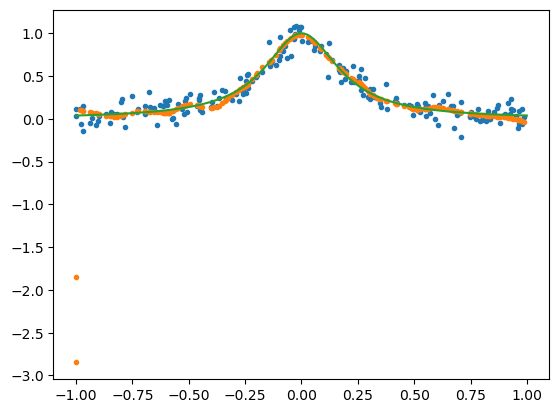

In [220]:
print(mean_squared_error(test_pred, y_test))

plt.plot(XX_test_sorted, y_test_sorted, '.')
plt.plot(XX_test_sorted, test_pred_sorted, '.')
plt.plot(x, Runge_func(x), "-")

In [ ]:
np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_size = 7
epochs = 100

scheduler = Adam(0.001)
ffnn = NeuralNetwork(num_input_feats, 
                     num_output_feats,
                     [200,200],
                     [sigmoid, sigmoid, id_func], 
                     [sigmoid_der, sigmoid_der, id_func_der],
                     scheduler, 
                     mse, 
                     mse_der,
                     regularization = None, reg_param=0,
                     seed=2025
                    )



#Train
ffnn.train(X_train_s.reshape(-1,1), y_train_s, batch_size, epochs)

test_pred = ffnn.predict(X_test_s[:, 0].reshape(-1,1))

test_pred = scaler_y.inverse_transform(test_pred)

mean_squared_error(test_pred, y_test)